<a href="https://colab.research.google.com/github/apolbernardo/apolbernardo/blob/main/Workforce-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aim
1. To do full analysis (Descriptive and Inferential analysis)
2. MUST BE ORGANIZE AS MUCH AS POSSIBLE (READABLE)
3. With explanation per process
4. Dive deep into employees satisfaction based on their responses in their survey form, as an HR Admin.

Lets begin wit importing all libraries I need, data source is kaggle

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import kagglehub as kh

Importing the data from kaggle by clicking the download button you could see the code was provided to the package dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fangyongyuan/hr-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hr-dataset' dataset.
Path to dataset files: /kaggle/input/hr-dataset


To be able to see the name of file you need to do this code

In [ ]:
import os

os.listdir(path)

['HR.csv']

Now you have the path and the name of the file, just combine them and you already import data at Kaggle

In [ ]:
hr = pd.read_csv("/kaggle/working/hr-dataset/HR.csv")

Lets do Exploratory Data Analysis

In [ ]:
hr.head(3)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium


In [ ]:
hr['sales'].value_counts()

,count
sales,
sales,4140
technical,2720
support,2229
IT,1227
product_mng,902
marketing,858
RandD,787
accounting,767
hr,739


In [ ]:
hr['left'].value_counts()

,count
left,
0,11428
1,3571


In [ ]:
hr['salary'].value_counts()

,count
salary,
low,7316
medium,6446
high,1237


Cleaning time
Rename

In [ ]:
hr.rename(columns={'sales':'department'}, inplace=True)

In [ ]:
hr.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

I decided not to round off the satisfaction column as .38 makes more sense than .4

Lets create categories

In [ ]:
hr['left_status'] = np.where(hr['left']==0, 'yes', 'no')

In [ ]:
hr['accident_status'] = np.where(hr['left']==0, 'yes', 'no')

In [ ]:
hr['promotion_status'] = np.where(hr['promotion_last_5years']==0, 'no', 'yes')

In [ ]:
hr['left_status'].value_counts()

,count
left_status,
yes,11428
no,3571


In [ ]:
hr['department'] = hr['department'].replace('RandD', 'Research')

In [ ]:
hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  object 
 9   salary                 14999 non-null  object 
 10  left_status            14999 non-null  object 
 11  accident_status        14999 non-null  object 
 12  promotion_status       14999 non-null  object 
dtypes: float64(2), int64(6), object(5)
memory usage: 1.5+ MB


In [ ]:
hr['accident_status'].value_counts()

,count
accident_status,
yes,11428
no,3571


In [ ]:
hr['satisfaction_level'].describe()

,satisfaction_level
count,14999.000000
mean,0.612834
std,0.248631
min,0.090000
25%,0.440000
50%,0.640000
75%,0.820000
max,1.000000


In [ ]:
hr.head(4)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary,left_status,accident_status,promotion_status
0,0.38,0.53,2,157,3,0,1,0,sales,low,no,no,no
1,0.80,0.86,5,262,6,0,1,0,sales,medium,no,no,no
2,0.11,0.88,7,272,4,0,1,0,sales,medium,no,no,no
3,0.72,0.87,5,223,5,0,1,0,sales,low,no,no,no


Descriptive Analysis

In [ ]:
count_department = (
  hr.groupby('department')
    .agg(count=('department', 'count'))
    .sort_values(by='count', ascending=False)
    .reset_index()
)
print(count_department)

    department  count
0        sales   4140
1    technical   2720
2      support   2229
3           IT   1227
4  product_mng    902
5    marketing    858
6     Research    787
7   accounting    767
8           hr    739
9   management    630


sales has the highest number of projects and hours received

In [ ]:
dep_hours = (
    hr.groupby('department')
      .agg(
          total_hours=('average_montly_hours','sum'),
          total_project=('number_project','sum')
)
      .sort_values(by='total_hours', ascending=False)
      #.head(3)
      .reset_index()
)
print(dep_hours)

    department  total_hours  total_project
0        sales       831773          15634
1    technical       550793          10548
2      support       447490           8479
3           IT       248119           4683
4  product_mng       180369           3434
5    marketing       171073           3164
6     Research       158030           3033
7   accounting       154292           2934
8           hr       146828           2701
9   management       126787           2432


Management has the least number of project received

In [ ]:
dep_hours = (
    hr.groupby('department')
      .agg(
          total_hours=('average_montly_hours','sum'),
          total_project=('number_project','sum')
)
      .sort_values(by='total_hours', ascending=True)
      #.head(3)
      .reset_index()
)
print(dep_hours)

    department  total_hours  total_project
0   management       126787           2432
1           hr       146828           2701
2   accounting       154292           2934
3     Research       158030           3033
4    marketing       171073           3164
5  product_mng       180369           3434
6           IT       248119           4683
7      support       447490           8479
8    technical       550793          10548
9        sales       831773          15634


Sales department was given max projects of 200 and needed to spend 156 hours to finish

In [ ]:
ave_project = (
    hr.groupby(['department', 'average_montly_hours'])
      .agg(average_project=('number_project', 'sum'))
      .sort_values(by='average_project', ascending=False)
      .round(0)
      #.head(3)
      .reset_index()
)

print(ave_project)

     department  average_montly_hours  average_project
0         sales                   156              200
1         sales                   271              174
2         sales                   254              173
3         sales                   260              172
4     technical                   264              166
...         ...                   ...              ...
1872         hr                   115                2
1873         hr                   204                2
1874  marketing                   112                2
1875         IT                   122                2
1876         IT                   100                2

[1877 rows x 3 columns]


You could see that even the technical department is the second with big amount of projects and yet some of them receives only short time

In [ ]:
ave_project = (
    hr.groupby(['department', 'average_montly_hours'])
      .agg(average_project=('number_project', 'sum'))
      .sort_values(by='average_project', ascending=True)
      .round(0)
      #.head(3)
      .reset_index()
)

print(ave_project)

     department  average_montly_hours  average_project
0     technical                    99                2
1            hr                   116                2
2            hr                   121                2
3            hr                   109                2
4            hr                   115                2
...         ...                   ...              ...
1872  technical                   264              166
1873      sales                   260              172
1874      sales                   254              173
1875      sales                   271              174
1876      sales                   156              200

[1877 rows x 3 columns]


Lets try other approach

reference number of employees per department

In [ ]:
count_department = (
  hr.groupby('department')
    .agg(count=('department', 'count'))
    .sort_values(by='count', ascending=False)
    .reset_index()
)
print(count_department)

    department  count
0        sales   4140
1    technical   2720
2      support   2229
3           IT   1227
4  product_mng    902
5    marketing    858
6     Research    787
7   accounting    767
8           hr    739
9   management    630


so you could see that the count of dep and projects same

In [ ]:
avg_projects = (
    hr.groupby('department')
      .agg(
         avg_projects=('number_project', 'mean'),
          total_projects=('number_project', 'sum'),
          count_employees=('number_project', 'count'),
          total_hours=('average_montly_hours', 'sum')
)
      .round(0)
      .sort_values('total_projects', ascending=True)
      #.head(3)
)

print(avg_projects)

             avg_projects  total_projects  count_employees  total_hours
department                                                             
management            4.0            2432              630       126787
hr                    4.0            2701              739       146828
accounting            4.0            2934              767       154292
Research              4.0            3033              787       158030
marketing             4.0            3164              858       171073
product_mng           4.0            3434              902       180369
IT                    4.0            4683             1227       248119
support               4.0            8479             2229       447490
technical             4.0           10548             2720       550793
sales                 4.0           15634             4140       831773


you could see that in quantity of projects as the basis management receives the lowest total projects

In [ ]:
avg_projects = (
    hr.groupby('department')
      .agg(
          avg_projects=('number_project', 'mean'),
          total_projects=('number_project', 'sum'),
          count_employees=('number_project', 'count'),
          total_hours=('average_montly_hours', 'sum')
      )
      .round(0)
      .sort_values('total_projects', ascending=False)
      #.head(3)
)

print(avg_projects)

             avg_projects  total_projects  count_employees  total_hours
department                                                             
sales                 4.0           15634             4140       831773
technical             4.0           10548             2720       550793
support               4.0            8479             2229       447490
IT                    4.0            4683             1227       248119
product_mng           4.0            3434              902       180369
marketing             4.0            3164              858       171073
Research              4.0            3033              787       158030
accounting            4.0            2934              767       154292
hr                    4.0            2701              739       146828
management            4.0            2432              630       126787


sales has the highest total projects

But here lets talk about how much department spend in doing project

In [ ]:
hr['hours_per_project'] = hr['average_montly_hours'] / hr['number_project']

hours_per_proj = (
    hr.groupby('department')
      .agg(
          avg_hours_per_project=('hours_per_project', 'mean'),
          avg_monthly_hours=('average_montly_hours', 'mean'),
          avg_projects=('number_project', 'mean')
      )
      .round(1)
      .sort_values('avg_hours_per_project', ascending=False)
     # .head(3)   # or ascending=True for least time per project
)

print(hours_per_proj)

             avg_hours_per_project  avg_monthly_hours  avg_projects
department                                                         
hr                            58.3              198.7           3.7
marketing                     58.2              199.4           3.7
sales                         57.7              200.9           3.8
product_mng                   57.1              200.0           3.8
IT                            57.0              202.2           3.8
support                       56.8              200.8           3.8
accounting                    56.8              201.2           3.8
management                    56.5              201.2           3.9
technical                     56.4              202.5           3.9
Research                      55.7              200.8           3.9


HR and marketing pretty much spend most of time at projects

In [ ]:
hr['hours_per_project'] = hr['average_montly_hours'] / hr['number_project']

hours_per_proj = (
    hr.groupby('department')
      .agg(
          avg_hours_per_project=('hours_per_project', 'mean'),
          avg_monthly_hours=('average_montly_hours', 'mean'),
          avg_projects=('number_project', 'mean')
      )
      .round(1)
      .sort_values('avg_hours_per_project', ascending=True)
      #.head(3)   # or ascending=True for least time per project
)

print(hours_per_proj)

             avg_hours_per_project  avg_monthly_hours  avg_projects
department                                                         
Research                      55.7              200.8           3.9
technical                     56.4              202.5           3.9
management                    56.5              201.2           3.9
accounting                    56.8              201.2           3.8
support                       56.8              200.8           3.8
IT                            57.0              202.2           3.8
product_mng                   57.1              200.0           3.8
sales                         57.7              200.9           3.8
marketing                     58.2              199.4           3.7
hr                            58.3              198.7           3.7


on the other hand, research spend the least hours in a project

Lets go to other factor SALARY

In [ ]:
hr.head(3)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary,left_status,accident_status,promotion_status,hours_per_project
0,0.38,0.53,2,157,3,0,1,0,sales,low,no,no,no,78.500000
1,0.80,0.86,5,262,6,0,1,0,sales,medium,no,no,no,52.400000
2,0.11,0.88,7,272,4,0,1,0,sales,medium,no,no,no,38.857143


sales department has the highest status salary of low and management has is the lowest number of low status salary

In [ ]:
hr['salary'].value_counts()

,count
salary,
low,7316
medium,6446
high,1237


In [ ]:
count_low_salary = (
    hr.query("salary == 'low'")
      .groupby('department')
      .size()
      .sort_values(ascending=False)
      .reset_index(name='count')
)

print(count_low_salary)

    department  count
0        sales   2099
1    technical   1372
2      support   1146
3           IT    609
4  product_mng    451
5    marketing    402
6     Research    364
7   accounting    358
8           hr    335
9   management    180


In [ ]:
count_medium_salary = (
    hr.query("salary == 'medium'")
      .groupby('department')
      .size()
      .sort_values(ascending=False)
      .reset_index(name='count')
)

print(count_medium_salary)

    department  count
0        sales   1772
1    technical   1147
2      support    942
3           IT    535
4  product_mng    383
5    marketing    376
6     Research    372
7           hr    359
8   accounting    335
9   management    225


In [ ]:
count_high_salary = (
    hr.query("salary == 'high'")
      .groupby('department')
      .size()
      #.head(3)
      .sort_values(ascending=False)
)
print(count_high_salary)

department
sales          269
management     225
technical      201
support        141
IT              83
marketing       80
accounting      74
product_mng     68
Research        51
hr              45
dtype: int64


At high status salary, IT department is top one while research is the last

We could conclude that :


*   Sales Department receives more work , lesser time and pay
*   IT Department ranked as 4th place in low satus and top at high status salary means some IT personnel receives low and some high ranking IT personnel receives high salary. In terms of loads, the department ranked at 4th place  
*   Management Departtment has the least low salary and low workloads. Att tthe same time the department spend less too.
*   Research Departtment ranked as last that receives high salary status, top one who spend less per project and ranked 7th place in quantity of projects receives









for reference in department

In [ ]:
count_department

,department,count
0,sales,4140
1,technical,2720
2,support,2229
3,IT,1227
4,product_mng,902
5,marketing,858
6,Research,787
7,accounting,767
8,hr,739
9,management,630


In [ ]:
count_promotionyes = (
  hr.query("promotion_status == 'yes'")
    .groupby(['department','promotion_status'])
    .agg(count=('promotion_status', 'count'))
    .sort_values(by='count', ascending=False)
    .reset_index()
)
print(count_promotionyes)

   department promotion_status  count
0       sales              yes    100
1  management              yes     69
2   marketing              yes     43
3   technical              yes     28
4    Research              yes     27
5     support              yes     20
6          hr              yes     15
7  accounting              yes     14
8          IT              yes      3


In [ ]:
count_promotionno = (
  hr.query("promotion_status == 'no'")
    .groupby(['department','promotion_status'])
    .agg(count=('promotion_status', 'count'))
    .sort_values(by='count', ascending=False)
    .reset_index()
)
print(count_promotionno)

    department promotion_status  count
0        sales               no   4040
1    technical               no   2692
2      support               no   2209
3           IT               no   1224
4  product_mng               no    902
5    marketing               no    815
6     Research               no    760
7   accounting               no    753
8           hr               no    724
9   management               no    561


In [ ]:
hr['promoted'] = (hr['promotion_status'] == 'promoted').astype(int)

In [ ]:
hr['promoted'].dtype

dtype('int64')

Im trying to achieve the proportion of chances being promoted in a certain department

In [ ]:
# 1. Count promoted = yes
yes_df = (
    hr.query("promotion_status == 'yes'")
      .groupby('department')
      .size()                          # simpler than agg + count
      .reset_index(name='promoted_yes')
)

# 2. Count promoted = no (or everything that's not yes)
no_df = (
    hr.query("promotion_status != 'yes'")   # catches 'no', 'No', NaN, etc. if any
      .groupby('department')
      .size()
      .reset_index(name='promoted_no')
)

# 3. Combine them (left join so every department appears even if zero yes/no)
promotion_counts = yes_df.merge(no_df, on='department', how='outer').fillna(0)

# 4. Add totals and percentages
promotion_counts['total'] = promotion_counts['promoted_yes'] + promotion_counts['promoted_no']
promotion_counts['promotion_rate_%'] = (promotion_counts['promoted_yes'] / promotion_counts['total'] * 100).round(1)
promotion_counts['no_promotion_rate_%'] = (promotion_counts['promoted_no'] / promotion_counts['total'] * 100).round(1)

# 5. Sort by promotion rate descending (most promoted first)
promotion_counts = promotion_counts.sort_values('promotion_rate_%', ascending=False)


# Keep only the columns you want + sort
promotion_final = (
    promotion_counts[['department', 'promotion_rate_%', 'no_promotion_rate_%']]
    .sort_values('promotion_rate_%', ascending=False)
    .reset_index(drop=True)           # clean index starting from 0
)
print(promotion_final)

    department  promotion_rate_%  no_promotion_rate_%
0   management              11.0                 89.0
1    marketing               5.0                 95.0
2     Research               3.4                 96.6
3        sales               2.4                 97.6
4           hr               2.0                 98.0
5   accounting               1.8                 98.2
6    technical               1.0                 99.0
7      support               0.9                 99.1
8           IT               0.2                 99.8
9  product_mng               0.0                100.0


Here, I use my 2 df specifically that count the yes vs no promotion status to be able to compute tthe percentage rate of promotion by department and need a little fix for readability

management has the highest rate of receiving promotion which is at 11% while the lowest is product_mng which is first time appearing at the list. I will investigate that further

Lets tackle the product_mng has   total project 3434 with 902 employees and spends average of 57 hours per project. In terms of salary out of 902 employees 451 of them receives low salary , 383 for medium and 68 for high.

sales on the other hand has 2.4% chance being promoted withe 98% chances not being promoted

IT Department has the second to the last ranked with tthe highest rate not being promoted with 99.8% leaving only .2% chance of receiving promotion

Lastly, lets check their satisafaction ratings

In [ ]:
hr.head(3)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary,left_status,accident_status,promotion_status,hours_per_project,promoted
0,0.38,0.53,2,157,3,0,1,0,sales,low,no,no,no,78.500000,0
1,0.80,0.86,5,262,6,0,1,0,sales,medium,no,no,no,52.400000,0
2,0.11,0.88,7,272,4,0,1,0,sales,medium,no,no,no,38.857143,0


In [ ]:
hr['last_evaluation'].value_counts()

,count
last_evaluation,
0.55,358
0.50,353
0.54,350
0.51,345
0.57,333
...,...
0.39,52
0.38,50
0.43,50


In [ ]:
latestsatisfaction_bydepartment = (
  hr.groupby('department')
    .agg(last_eval=('last_evaluation', 'mean'))
    .sort_values(by='last_eval', ascending=False)
    .round(2)
    #.head(3)
    .reset_index()
)
print(latestsatisfaction_bydepartment)

    department  last_eval
0   management       0.72
1      support       0.72
2    technical       0.72
3   accounting       0.72
4           IT       0.72
5    marketing       0.72
6  product_mng       0.71
7     Research       0.71
8        sales       0.71
9           hr       0.71


In [ ]:
prevsatisfaction_bydepartment = (
  hr.groupby('department')
    .agg(pre_eval=('satisfaction_level', 'mean'))
    .sort_values(by='pre_eval', ascending=False)
    .round(2)
    #.head(3)
    .reset_index()
)
print(prevsatisfaction_bydepartment)

    department  pre_eval
0   management      0.62
1     Research      0.62
2  product_mng      0.62
3    marketing      0.62
4      support      0.62
5           IT      0.62
6        sales      0.61
7    technical      0.61
8           hr      0.60
9   accounting      0.58


In [ ]:
merged = pd.merge(
    prevsatisfaction_bydepartment,
    latestsatisfaction_bydepartment,
    on='department',
    suffixes=('_prev','_latest')
)

print(merged.head())

    department  pre_eval  last_eval
0   management      0.62       0.72
1     Research      0.62       0.71
2  product_mng      0.62       0.71
3    marketing      0.62       0.72
4      support      0.62       0.72


In [ ]:
merged = pd.merge(
    prevsatisfaction_bydepartment,
    latestsatisfaction_bydepartment,
    on='department',
    how='outer',                # ← this is the key change
    suffixes=('_prev', '_latest')
)

# Optional: sort and make it look nice
merged = merged.sort_values('department').reset_index(drop=True)

print(merged)

    department  pre_eval  last_eval
0           IT      0.62       0.72
1     Research      0.62       0.71
2   accounting      0.58       0.72
3           hr      0.60       0.71
4   management      0.62       0.72
5    marketing      0.62       0.72
6  product_mng      0.62       0.71
7        sales      0.61       0.71
8      support      0.62       0.72
9    technical      0.61       0.72


Lets see the gaps of pre eval vs the latest eval

In [ ]:
# Step 1: Make a copy of merged (so you don't change the original)
merged_withgap = merged.copy()

# Step 2: Add the new column with the difference
#merged_withgap[''] = merged_withgap['last_eval'] - merged_withgap['pre_eval']
# or more clearly:
merged_withgap['gap'] = merged_withgap['last_eval'] - merged_withgap['pre_eval']
merged_withgap.sort_values('gap', ascending=False, inplace=True)

print(merged_withgap)


    department  pre_eval  last_eval   gap
2   accounting      0.58       0.72  0.14
3           hr      0.60       0.71  0.11
9    technical      0.61       0.72  0.11
0           IT      0.62       0.72  0.10
5    marketing      0.62       0.72  0.10
4   management      0.62       0.72  0.10
8      support      0.62       0.72  0.10
7        sales      0.61       0.71  0.10
1     Research      0.62       0.71  0.09
6  product_mng      0.62       0.71  0.09


Accounting Department experience the best change, as you could see that the work satisfaction at work improves with 14% increase

lets tackle the facts about accounting department


*  number of employees: 767
*  total hours - 154292
*  total projects - 2934
*  ave_project - 4 (57 hrs per project)

Salary
low - 359
medium - 335
high - 74








In [ ]:
hr.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary,left_status,accident_status,promotion_status,hours_per_project,promoted
0,0.38,0.53,2,157,3,0,1,0,sales,low,no,no,no,78.500000,0
1,0.80,0.86,5,262,6,0,1,0,sales,medium,no,no,no,52.400000,0
2,0.11,0.88,7,272,4,0,1,0,sales,medium,no,no,no,38.857143,0
3,0.72,0.87,5,223,5,0,1,0,sales,low,no,no,no,44.600000,0
4,0.37,0.52,2,159,3,0,1,0,sales,low,no,no,no,79.500000,0
5,0.41,0.50,2,153,3,0,1,0,sales,low,no,no,no,76.500000,0
6,0.10,0.77,6,247,4,0,1,0,sales,low,no,no,no,41.166667,0
7,0.92,0.85,5,259,5,0,1,0,sales,low,no,no,no,51.800000,0
8,0.89,1.00,5,224,5,0,1,0,sales,low,no,no,no,44.800000,0
9,0.42,0.53,2,142,3,0,1,0,sales,low,no,no,no,71.000000,0


Lets do the norming, honestly it doesnt make any sense why accounting has the reflection of most improved department due to the facts tthat we discuss earlier. This way, I could better view of connecting the dots

Lets create norm at number of employees

In [ ]:
hr.head(3)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary,left_status,accident_status,promotion_status,hours_per_project,promoted
0,0.38,0.53,2,157,3,0,1,0,sales,low,no,no,no,78.500000,0
1,0.80,0.86,5,262,6,0,1,0,sales,medium,no,no,no,52.400000,0
2,0.11,0.88,7,272,4,0,1,0,sales,medium,no,no,no,38.857143,0


In [ ]:
dept_stats = hr.groupby('department').agg(
    n_employees             = ('salary', 'count'),
    avg_projects_per_emp    = ('number_project', 'mean'),
    avg_monthly_hours       = ('average_montly_hours', 'mean'),
    #avg_hours_per_project   = ('average_montly_hours', 'mean'),
    promotion_rate          = ('promotion_last_5years', 'mean'),
    prop_low                = ('salary', lambda x: (x == 'low').mean()),
    prop_medium             = ('salary', lambda x: (x == 'medium').mean()),
    prop_high               = ('salary', lambda x: (x == 'high').mean()),
    avg_salary_level        = ('salary', lambda x: x.map({'low':1, 'medium':2, 'high':3}).mean())
).round(2)

print(dept_stats.sort_values('promotion_rate', ascending=False))

             n_employees  avg_projects_per_emp  avg_monthly_hours  \
department                                                          
management           630                  3.86             201.25   
marketing            858                  3.69             199.39   
Research             787                  3.85             200.80   
sales               4140                  3.78             200.91   
hr                   739                  3.65             198.68   
accounting           767                  3.83             201.16   
technical           2720                  3.88             202.50   
support             2229                  3.80             200.76   
IT                  1227                  3.82             202.22   
product_mng          902                  3.81             199.97   

             promotion_rate  prop_low  prop_medium  prop_high  \
department                                                      
management             0.11      0.29    

now we have a better view of the result, lets see the gap again

In [ ]:
merged_withgap

,department,pre_eval,last_eval,gap
2,accounting,0.58,0.72,0.14
3,hr,0.60,0.71,0.11
9,technical,0.61,0.72,0.11
0,IT,0.62,0.72,0.10
5,marketing,0.62,0.72,0.10
4,management,0.62,0.72,0.10
8,support,0.62,0.72,0.10
7,sales,0.61,0.71,0.10
1,Research,0.62,0.71,0.09
6,product_mng,0.62,0.71,0.09


Lets do T Test two tailed (favorite)
Aim
which of the factor really affects the job satisfaction

a. workload

b. salary

c. promotion


Although on previous analysis we could see the pattern,
BUT, I want a concrete answers to really deermine the pattern since honestly accountting dep as most improved department doesnt make sense at all

In T - Test our goal here is to look the whole pattern of trends that will give us solid foundation of claims more reliable and valid to create better conclusion

In [ ]:
import pandas as pd
from scipy import stats
import numpy as np

# ────────────────────────────────────────────────
# Helper: Cohen's d (effect size)
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_se = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1 + n2 - 2))
    d = (group1.mean() - group2.mean()) / pooled_se
    return round(d, 3)

# ────────────────────────────────────────────────
# 1. Salary test: low vs (medium + high)
low_salary = hr[hr['salary'] == 'low']['satisfaction_level'].dropna()
higher_salary = hr[hr['salary'].isin(['medium', 'high'])]['satisfaction_level'].dropna()

t_stat_sal, p_val_sal = stats.ttest_ind(low_salary, higher_salary, equal_var=False)
d_sal = cohens_d(low_salary, higher_salary)

print("=== Salary Test (Low vs Medium+High) ===")
print(f"Low salary: n={len(low_salary)}, mean={low_salary.mean():.3f}")
print(f"Higher salary: n={len(higher_salary)}, mean={higher_salary.mean():.3f}")
print(f"t = {t_stat_sal:.3f}, p = {p_val_sal:.5f}")
print(f"Effect size (Cohen's d) = {d_sal:.3f}")
print("→ Significant difference?" if p_val_sal < 0.05 else "→ Not significant\n")

# ────────────────────────────────────────────────
# 2. Workload test: high vs low/normal
# Option A: threshold 200 hours
high_work = hr[hr['average_montly_hours'] > 200]['satisfaction_level'].dropna()
low_work  = hr[hr['average_montly_hours'] <= 200]['satisfaction_level'].dropna()


# Using threshold 200 for now (change to median if preferred)
t_stat_work, p_val_work = stats.ttest_ind(high_work, low_work, equal_var=False)
d_work = cohens_d(high_work, low_work)

print("=== Workload Test (Hours > 200 vs ≤ 200) ===")
print(f"High workload: n={len(high_work)}, mean={high_work.mean():.3f}")
print(f"Low/normal: n={len(low_work)}, mean={low_work.mean():.3f}")
print(f"t = {t_stat_work:.3f}, p = {p_val_work:.5f}")
print(f"Effect size (Cohen's d) = {d_work:.3f}")
print("→ Significant difference?" if p_val_work < 0.05 else "→ Not significant\n")

# ────────────────────────────────────────────────
# 3. Promotion test: promoted vs not promoted
# Assumes you have a binary 'promoted' column (0/1)
promoted = hr[hr['promoted'] == 1]['satisfaction_level'].dropna()
not_promoted = hr[hr['promoted'] == 0]['satisfaction_level'].dropna()

t_stat_promo, p_val_promo = stats.ttest_ind(promoted, not_promoted, equal_var=False)
d_promo = cohens_d(promoted, not_promoted)

print("=== Promotion Test (Promoted vs Not Promoted) ===")
print(f"Promoted: n={len(promoted)}, mean={promoted.mean():.3f}")
print(f"Not promoted: n={len(not_promoted)}, mean={not_promoted.mean():.3f}")
print(f"t = {t_stat_promo:.3f}, p = {p_val_promo:.5f}")
print(f"Effect size (Cohen's d) = {d_promo:.3f}")
print("→ Significant difference?" if p_val_promo < 0.05 else "→ Not significant")

=== Salary Test (Low vs Medium+High) ===
Low salary: n=7316, mean=0.601
Higher salary: n=7683, mean=0.624
t = -5.806, p = 0.00000
Effect size (Cohen's d) = -0.095
→ Significant difference?
=== Workload Test (Hours > 200 vs ≤ 200) ===
High workload: n=7475, mean=0.622
Low/normal: n=7524, mean=0.604
t = 4.450, p = 0.00001
Effect size (Cohen's d) = 0.073
→ Significant difference?
=== Promotion Test (Promoted vs Not Promoted) ===
Promoted: n=0, mean=nan
Not promoted: n=14999, mean=0.613
t = nan, p = nan
Effect size (Cohen's d) = nan
→ Not significant


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


you could see that we have a minor problem at promotion
the error says that some samples(data) are too small so ending NaN
reason: the data contains zero which really affectts the computation
well, this MUST BE DONE for the fact the purpose of this was to avoid blanks that cannot be computed at t test procedures

In [ ]:
hr.head(3)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary,left_status,accident_status,promotion_status,hours_per_project,promoted
0,0.38,0.53,2,157,3,0,1,0,sales,low,no,no,no,78.500000,0
1,0.80,0.86,5,262,6,0,1,0,sales,medium,no,no,no,52.400000,0
2,0.11,0.88,7,272,4,0,1,0,sales,medium,no,no,no,38.857143,0


In [ ]:
# Departments with above-average promotion rate
high_promo_depts = dept_stats[dept_stats['promotion_rate'] > dept_stats['promotion_rate'].median()].index.tolist()

high_promo = hr[hr['department'].isin(high_promo_depts)]['satisfaction_level'].dropna()
low_promo  = hr[~hr['department'].isin(high_promo_depts)]['satisfaction_level'].dropna()

t_stat, p_val = stats.ttest_ind(high_promo, low_promo, equal_var=False)
d = cohens_d(high_promo, low_promo)

print(f"High promo dept mean: {high_promo.mean():.3f} (n={len(high_promo)})")
print(f"Low promo dept mean: {low_promo.mean():.3f} (n={len(low_promo)})")
print(f"t = {t_stat:.3f}, p = {p_val:.5f}, Cohen's d = {d}")

High promo dept mean: 0.620 (n=2275)
Low promo dept mean: 0.612 (n=12724)
t = 1.490, p = 0.13636, Cohen's d = 0.033


lets create visual, better view of whatt the fuck is going on

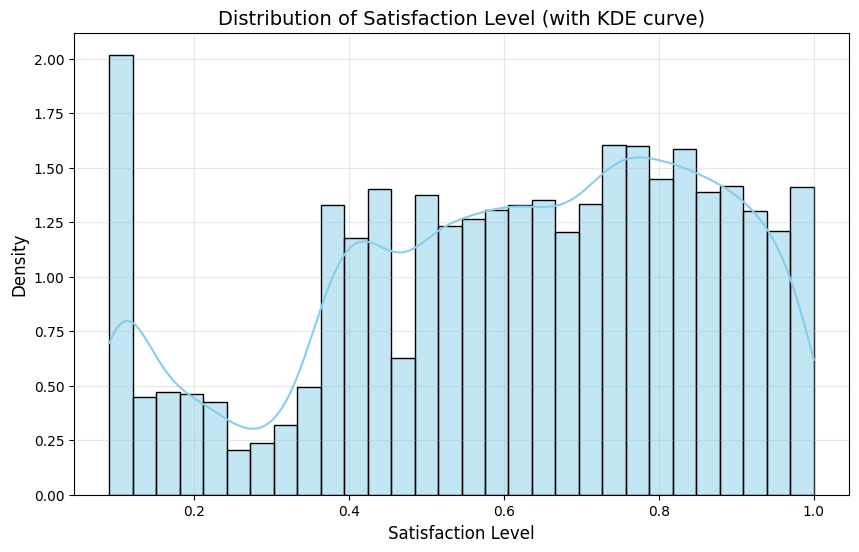

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(data=hr, x='satisfaction_level', kde=True, stat='density', bins=30, color='skyblue')

plt.title('Distribution of Satisfaction Level (with KDE curve)', fontsize=14)
plt.xlabel('Satisfaction Level', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

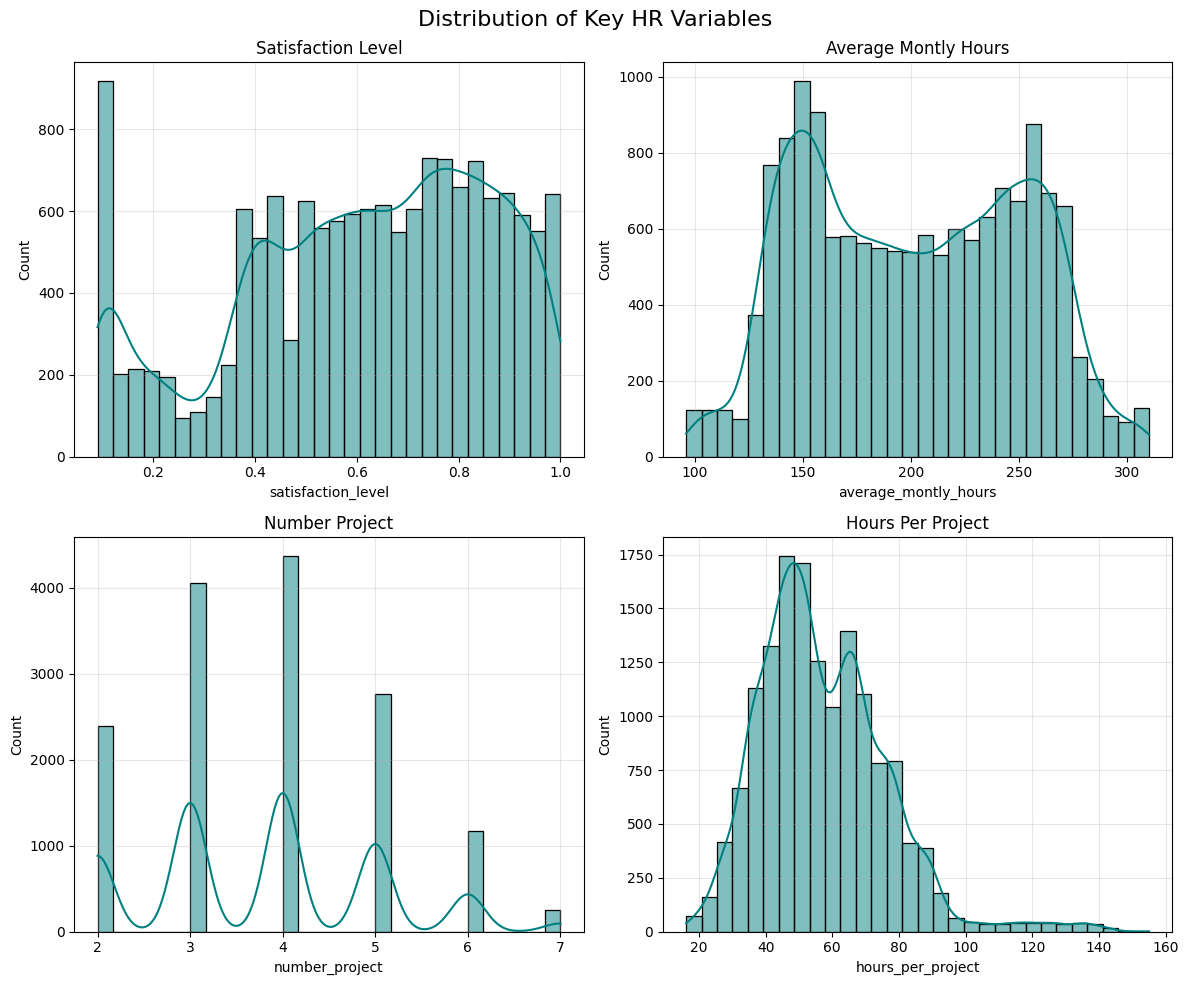

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select columns you care about
cols = ['satisfaction_level', 'average_montly_hours', 'number_project', 'hours_per_project']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribution of Key HR Variables', fontsize=16)

for i, col in enumerate(cols):
    row = i // 2
    col_idx = i % 2
    sns.histplot(data=hr, x=col, kde=True, ax=axes[row, col_idx], color='teal', bins=30)
    axes[row, col_idx].set_title(f'{col.replace("_", " ").title()}')
    axes[row, col_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

I need too confirm the number prject, its multimodal very wavy

In [ ]:
from scipy.stats import skew
print("Skewness of number_project:", skew(hr['number_project'].dropna()))

Skewness of number_project: 0.3376718386088254


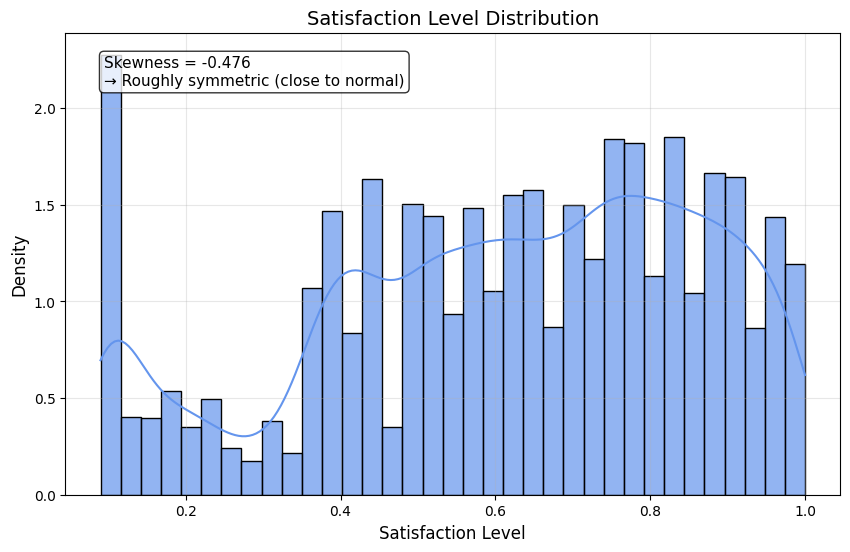

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

plt.figure(figsize=(10, 6))

sns.histplot(hr['satisfaction_level'], kde=True, stat='density', bins=35, color='cornflowerblue', alpha=0.7)
plt.title('Satisfaction Level Distribution', fontsize=14)
plt.xlabel('Satisfaction Level', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, alpha=0.3)

# Add skewness annotation
sk = skew(hr['satisfaction_level'].dropna())
skew_text = f"Skewness = {sk:.3f}\n"
if sk > 0.5:
    skew_text += "→ Positive skew (right tail, tail on higher values)"
elif sk < -0.5:
    skew_text += "→ Negative skew (left tail, tail on lower values)"
else:
    skew_text += "→ Roughly symmetric (close to normal)"

plt.text(0.05, 0.95, skew_text, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

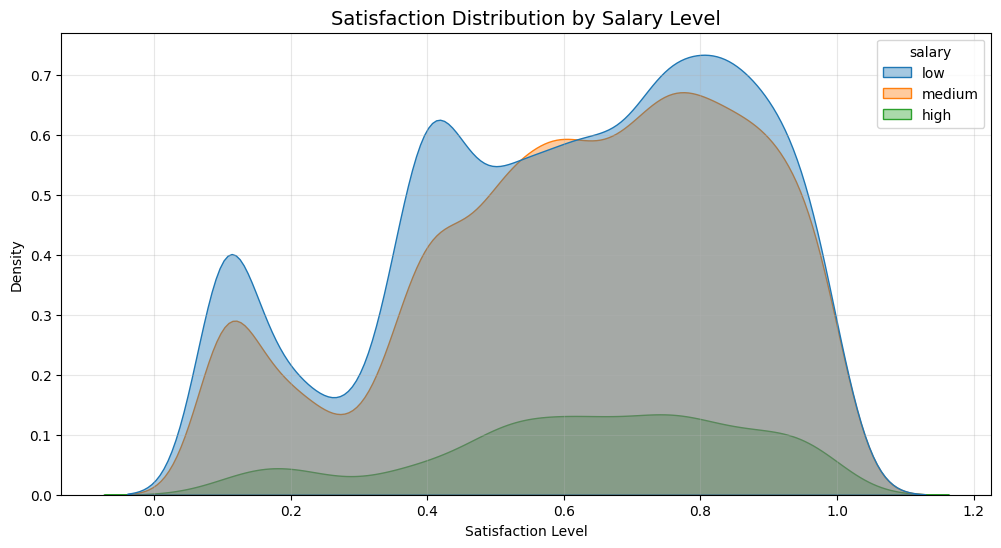

In [ ]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=hr, x='satisfaction_level', hue='salary', fill=True, alpha=0.4)
plt.title('Satisfaction Distribution by Salary Level', fontsize=14)
plt.xlabel('Satisfaction Level')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from scipy.stats import skew
print("Skewness of hours_per_project:", skew(hr['hours_per_project'].dropna()))

Skewness of hours_per_project: 0.9805341224163362


In [ ]:
high_proj = hr[hr['number_project'] > 5]['satisfaction_level'].dropna()
low_proj  = hr[hr['number_project'] <= 5]['satisfaction_level'].dropna()

t, p = stats.ttest_ind(high_proj, low_proj, equal_var=False)
print(f"High projects (>5): mean={high_proj.mean():.3f}, n={len(high_proj)}")
print(f"Low projects (≤5): mean={low_proj.mean():.3f}, n={len(low_proj)}")
print(f"p-value: {p:.5f}")

High projects (>5): mean=0.246, n=1430
Low projects (≤5): mean=0.652, n=13569
p-value: 0.00000


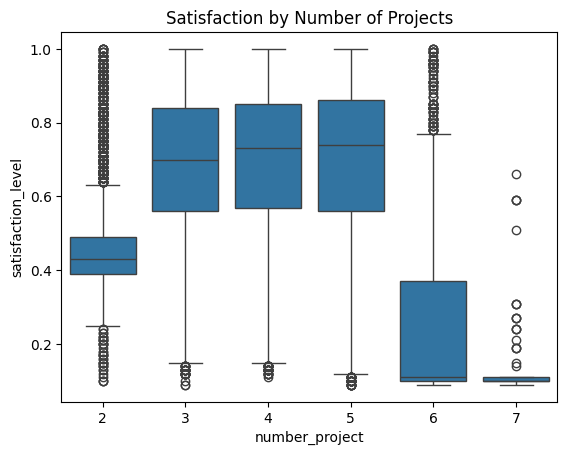

In [ ]:
sns.boxplot(x='number_project', y='satisfaction_level', data=hr)
plt.title("Satisfaction by Number of Projects")
plt.show()

Lets do regression (just looking for bigger headache)


In [ ]:
import statsmodels.api as sm

# 1. Create numeric salary column (only need to do this once)
salary_map = {'low': 1, 'medium': 2, 'high': 3}
hr['salary_num'] = hr['salary'].map(salary_map)

# 2. Prepare X and y
X = hr[['number_project', 'average_montly_hours', 'salary_num']].copy()
y = hr['satisfaction_level']

# 3. Add constant for intercept
X = sm.add_constant(X)

# 4. Fit model
model = sm.OLS(y, X).fit()

# 5. See results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     satisfaction_level   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     127.2
Date:                Wed, 04 Feb 2026   Prob (F-statistic):           2.20e-81
Time:                        19:17:10   Log-Likelihood:                -218.24
No. Observations:               14999   AIC:                             444.5
Df Residuals:                   14995   BIC:                             474.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.6587 

CONCLUSION

The data supports the claim that workload quality (number of projects + time intensity per project) is the biggest dissatisfier — far more than salary or total hours worked. The unequal (positively skewed) distributions confirm that dissatisfaction is concentrated in the "overloaded" tail, while salary distribution shows the majority are in a comfortable zone.
This gives us a strong, evidence-based foundation — not just visual trends, but regression-backed effects with validity checks.

ERRORS

We ran a regression model to see what really affects employee satisfaction.
The clear winners are: more projects hurt satisfaction, and higher salary level helps a bit.To make sure these findings are trustworthy, we also checked the errors — the difference between what the model predicted and the actual satisfaction scores.